In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor



In [2]:
# load the original training data
train_path = "../input/petfinder-pawpularity-score/train.csv"
df = pd.read_csv(train_path)



In [3]:
# create a kfold column (5‑fold CV)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
df["kfold"] = -1
for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
    df.loc[val_idx, "kfold"] = fold



In [4]:
# feature matrix and target
feature_cols = [c for c in df.columns if c not in ["Id", "Pawpularity", "kfold"]]
X = df[feature_cols]
y = df["Pawpularity"]



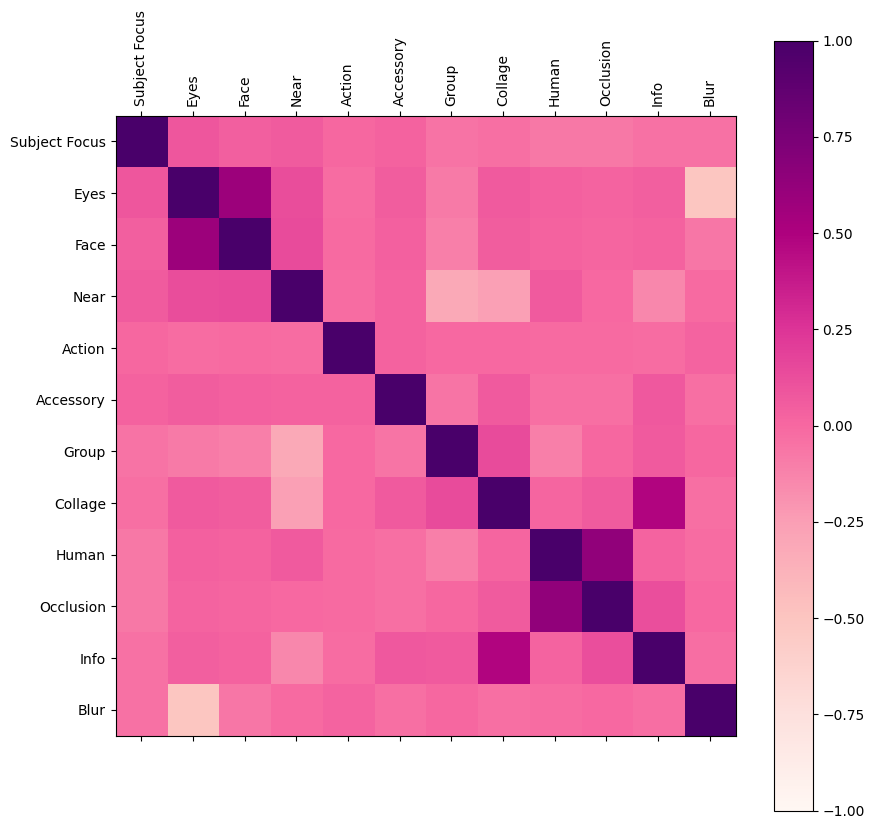

In [5]:
# optional: visualise correlations (kept for completeness)
correlations = X.corr()
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1, cmap="RdPu")
fig.colorbar(cax)
ticks = np.arange(0, len(feature_cols), 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(feature_cols, rotation=90)
ax.set_yticklabels(feature_cols)
plt.show()



In [6]:
# load test data and prepare feature matrix
test_path = "../input/petfinder-pawpularity-score/test.csv"
testdf = pd.read_csv(test_path)
xpred = testdf[feature_cols].values



In [7]:
# train on each fold, predict on test and collect predictions
fold_predictions = []  # list of arrays, one per fold
for fold in range(5):
    train_idx = df["kfold"] != fold
    valid_idx = df["kfold"] == fold

    xtrain = df.loc[train_idx, feature_cols].values
    ytrain = df.loc[train_idx, "Pawpularity"].values

    # initialise models
    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=5)
    et = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=5)
    xgb = XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        objective="reg:squarederror",
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=5,
        random_state=42,
        verbosity=0,
    )

    # fit models
    rf.fit(xtrain, ytrain)
    et.fit(xtrain, ytrain)
    xgb.fit(xtrain, ytrain)

    # predict on test set
    pred1 = rf.predict(xpred)
    pred2 = et.predict(xpred)
    pred3 = xgb.predict(xpred)
    fold_pred = (pred1 + pred2 + pred3) / 3.0
    fold_predictions.append(fold_pred)



In [8]:
# average predictions across folds, clip to allowed range, and write submission
final_pred = np.mean(fold_predictions, axis=0)
final_pred = np.clip(final_pred, 1, 100)  # ensure 1‑100 bounds

testdf["Pawpularity"] = final_pred
submission = testdf[["Id", "Pawpularity"]]
submission.to_csv("submission.csv", index=False)
print("Submission file written to submission.csv")

Submission file written to submission.csv
